# Bagging on the Iris Dataset

This notebook shows how bagging works on the Iris dataset using a simple decision tree as the base learner.

We will:
- load the Iris data
- use two features for easy visualization
- train a BaggingClassifier
- compare predictions with the actual labels
- plot a decision boundary

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

In [27]:
# Load the Iris dataset
iris = load_iris(as_frame=True)
df = iris.frame.copy()
df['species'] = df['target'].map(dict(enumerate(iris.target_names)))

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


## Choose Features

For an easy visual explanation, we will use two features:
- sepal width
- petal length

These features are enough to show how bagging improves a decision tree's stability.

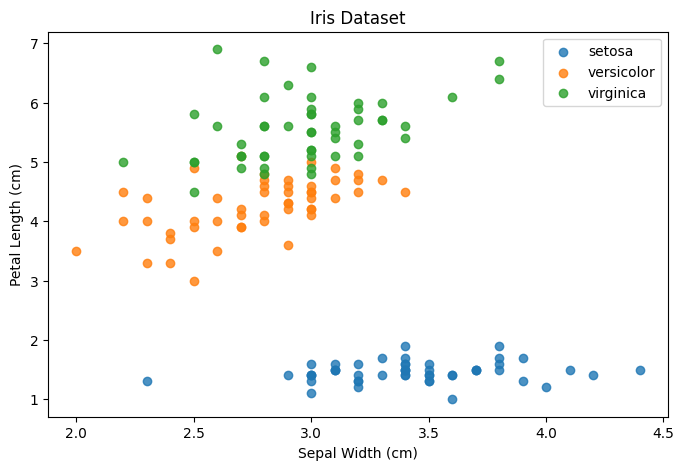

In [28]:
# Select two features for a 2D visualization
X = df[['sepal width (cm)', 'petal length (cm)']]
y = df['target']

plt.figure(figsize=(8, 5))
for target_value, species_name in enumerate(iris.target_names):
    mask = y == target_value
    plt.scatter(
        X.loc[mask, 'sepal width (cm)'],
        X.loc[mask, 'petal length (cm)'],
        label=species_name,
        alpha=0.8
    )

plt.xlabel('Sepal Width (cm)')
plt.ylabel('Petal Length (cm)')
plt.title('Iris Dataset')
plt.legend()
plt.show()

In [29]:
# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features for the classifier and plot later
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Training set shape:', X_train.shape)
print('Testing set shape:', X_test.shape)

Training set shape: (120, 2)
Testing set shape: (30, 2)


Accuracy: 0.9

Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



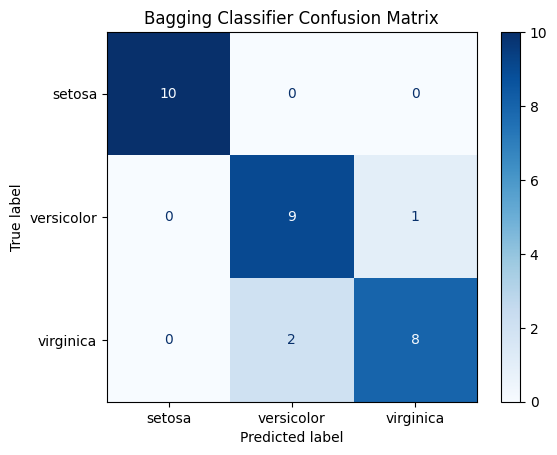

In [30]:
# Bagging model with a decision tree base estimator
base_tree = DecisionTreeClassifier(random_state=42)

bagging_model = BaggingClassifier(
    estimator=base_tree,
    n_estimators=25,
    random_state=42
)

bagging_model.fit(X_train_scaled, y_train)
y_pred = bagging_model.predict(X_test_scaled)

print('Accuracy:', accuracy_score(y_test, y_pred))
print('\nClassification Report:\n')
print(classification_report(y_test, y_pred, target_names=iris.target_names))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=iris.target_names).plot(cmap='Blues')
plt.title('Bagging Classifier Confusion Matrix')
plt.show()